# Walmart Sales Forecasting — N-BEATS

**მოდელი:** N-BEATS (Neural Basis Expansion Analysis for Time Series)  
**კატეგორია:** Deep Learning (Pure feed-forward, no RNN/attention)  
**ბიბლიოთეკა:** `neuralforecast` (Nixtla)  
**Logging:** WandB (project: `walmart-forecasting`)

**Runs:**
1. `NBEATS_DataPrep` — მონაცემების ტრანსფორმაცია long-format-ში
2. `NBEATS_Baseline` — default hyperparameters
3. `NBEATS_Interpretable` — trend + seasonality stacks
4. `NBEATS_LongContext` — გაზრდილი input_size
5. `NBEATS_Final` — საუკეთესო კონფიგურაცია



## 1. Setup

In [1]:
# ინსტალაცია
!pip install neuralforecast wandb --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 37.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS
from neuralforecast.losses.pytorch import MAE

import wandb
from pytorch_lightning.loggers import WandbLogger

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
# Drive mount
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/walmart'
DATA_DIR = f'{PROJECT_DIR}/data'
MODELS_DIR = f'{PROJECT_DIR}/models'

import os
os.makedirs(MODELS_DIR, exist_ok=True)
print(f"Data: {DATA_DIR}")
print(f"Models: {MODELS_DIR}")

Mounted at /content/drive
Data: /content/drive/MyDrive/walmart/data
Models: /content/drive/MyDrive/walmart/models


In [12]:
from google.colab import userdata

try:
    wandb_key = userdata.get('WANDB_API_KEY')
    wandb.login(key=wandb_key)
    print("WandB logged in")
except Exception as e:
    wandb.login()

WANDB_PROJECT = "walmart-forecasting"
print(f"WandB project: {WANDB_PROJECT}")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


WandB logged in
WandB project: walmart-forecasting


## 2. მონაცემების ჩატვირთვა და მომზადება

N-BEATS-ს სჭირდება **long-format** მონაცემები:
- `unique_id` — ცალკეული time series (Store × Dept კომბინაცია)
- `ds` — datestamp
- `y` — target (Weekly_Sales)

3000+ (Store, Dept) კომბინაცია → 3000+ ცალკე time series → ერთი global N-BEATS მოდელი ყველა მათგანზე ერთდროულად ტრენინგდება.

In [6]:
# Raw მონაცემები
train_raw = pd.read_csv(f'{DATA_DIR}/train.csv.zip')
test_raw = pd.read_csv(f'{DATA_DIR}/test.csv.zip')

train_raw['Date'] = pd.to_datetime(train_raw['Date'])
test_raw['Date'] = pd.to_datetime(test_raw['Date'])

print(f"Train: {train_raw.shape}")
print(f"Test:  {test_raw.shape}")
print(f"Unique stores: {train_raw['Store'].nunique()}")
print(f"Unique depts:  {train_raw['Dept'].nunique()}")
print(f"Unique (Store, Dept) combos: {train_raw.groupby(['Store', 'Dept']).ngroups}")

Train: (421570, 5)
Test:  (115064, 4)
Unique stores: 45
Unique depts:  81
Unique (Store, Dept) combos: 3331


In [7]:
# Long-format transformation
def to_nbeats_format(df, has_target=True):
    """Neuralforecast-ის required format-ში გადავყავართ."""
    df = df.copy()
    df['unique_id'] = df['Store'].astype(str) + '_' + df['Dept'].astype(str)
    df = df.rename(columns={'Date': 'ds'})
    if has_target:
        df = df.rename(columns={'Weekly_Sales': 'y'})
        return df[['unique_id', 'ds', 'y']]
    return df[['unique_id', 'ds']]


train_nf = to_nbeats_format(train_raw, has_target=True)
test_nf = to_nbeats_format(test_raw, has_target=False)

print(f"Train nf: {train_nf.shape}")
print(f"Test nf:  {test_nf.shape}")
print(f"\nSample:")
train_nf.head()

Train nf: (421570, 3)
Test nf:  (115064, 2)

Sample:


,unique_id,ds,y
0,1_1,2010-02-05,24924.50
1,1_1,2010-02-12,46039.49
2,1_1,2010-02-19,41595.55
3,1_1,2010-02-26,19403.54
4,1_1,2010-03-05,21827.90


In [8]:
# Time series length distribution — რამდენად გრძელი time series-ები გვაქვს?
series_lengths = train_nf.groupby('unique_id').size()
print(f"Time series count: {len(series_lengths)}")
print(f"Length stats:")
print(f"  Min:    {series_lengths.min()}")
print(f"  Median: {series_lengths.median():.0f}")
print(f"  Max:    {series_lengths.max()}")
print(f"  Mean:   {series_lengths.mean():.1f}")

# ძალიან მოკლე time series-ები N-BEATS-ს ეშლება, ვფილტრავთ
MIN_LENGTH = 52  # ერთი წელი მინიმუმ
valid_ids = series_lengths[series_lengths >= MIN_LENGTH].index
train_nf = train_nf[train_nf['unique_id'].isin(valid_ids)].reset_index(drop=True)

print(f"\nAfter filtering (min length {MIN_LENGTH}):")
print(f"  Time series: {train_nf['unique_id'].nunique()}")
print(f"  Total rows:  {len(train_nf)}")

Time series count: 3331
Length stats:
  Min:    1
  Median: 143
  Max:    143
  Mean:   126.6

After filtering (min length 52):
  Time series: 2991
  Total rows:  416615


## 3. Train/Val Split + WMAE Metric

In [9]:
def wmae(y_true, y_pred, weights):
    """Competition metric."""
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)


def evaluate_forecast(forecasts_df, val_df, train_raw_val):
    """
    N-BEATS-ის forecasts-ს ვადარებთ ვალიდაციის ground truth-ს.
    Weights ვიღებთ train_raw_val-იდან (IsHoliday-ის მიხედვით).
    """
    merged = forecasts_df.merge(val_df, on=['unique_id', 'ds'], how='inner')

    # IsHoliday-ს ვუბრუნდებით raw train-იდან
    train_raw_val_lookup = train_raw_val.copy()
    train_raw_val_lookup['unique_id'] = (
        train_raw_val_lookup['Store'].astype(str) + '_' + train_raw_val_lookup['Dept'].astype(str)
    )
    train_raw_val_lookup = train_raw_val_lookup.rename(columns={'Date': 'ds'})

    merged = merged.merge(
        train_raw_val_lookup[['unique_id', 'ds', 'IsHoliday']],
        on=['unique_id', 'ds'], how='left'
    )

    weights = np.where(merged['IsHoliday'] == True, 5, 1)
    return wmae(merged['y'].values, merged['NBEATS'].values, weights)

In [10]:
# Time-based split — ბოლო 12 კვირა ვალიდაცია
train_nf_sorted = train_nf.sort_values(['unique_id', 'ds']).reset_index(drop=True)

VAL_HORIZON = 12  # ბოლო 12 კვირა val-ისთვის

# Per-series split
def per_series_split(df, val_h):
    train_parts, val_parts = [], []
    for uid, group in df.groupby('unique_id'):
        group = group.sort_values('ds')
        if len(group) > val_h:
            train_parts.append(group.iloc[:-val_h])
            val_parts.append(group.iloc[-val_h:])
    return pd.concat(train_parts).reset_index(drop=True), pd.concat(val_parts).reset_index(drop=True)


train_split, val_split = per_series_split(train_nf_sorted, VAL_HORIZON)

# Raw train ვინახოთ val period-ისთვის (weights-ისთვის)
val_dates = val_split['ds'].unique()
train_raw_val_period = train_raw[train_raw['Date'].isin(val_dates)]

print(f"Train split: {train_split.shape}, series: {train_split['unique_id'].nunique()}")
print(f"Val split:   {val_split.shape}, series: {val_split['unique_id'].nunique()}")
print(f"Val date range: {val_split['ds'].min()} → {val_split['ds'].max()}")

Train split: (380723, 3), series: 2991
Val split:   (35892, 3), series: 2991
Val date range: 2010-11-26 00:00:00 → 2012-10-26 00:00:00


## 4. Run 1 — `NBEATS_Baseline`

Default N-BEATS კონფიგურაცია:
- Generic stack (interpretability გარეშე)
- Input size = 26 კვირა (ნახევარი წელი წარსული)
- Horizon = 12 კვირა (val period)
- 500 training steps

In [23]:
H = VAL_HORIZON  # forecast horizon = 12

BASELINE_CONFIG = {
    'h': H,
    'input_size': 26,
    'max_steps': 500,
    'learning_rate': 1e-3,
    'batch_size': 32,
    'stack_types': ['identity', 'identity', 'identity'],
    'n_blocks': [1, 1, 1],
    'mlp_units': 3 * [[256, 256]],
    'loss_name': 'MAE',
}

# WandB run
wandb.finish() if wandb.run else None

run = wandb.init(
    project=WANDB_PROJECT,
    name="NBEATS_Baseline",
    config=BASELINE_CONFIG,
    reinit=True,
    tags=['nbeats', 'baseline']
)

wandb_logger = WandbLogger(project=WANDB_PROJECT, name="NBEATS_Baseline", experiment=run)

model_baseline = NBEATS(
    h=H,
    input_size=BASELINE_CONFIG['input_size'],
    loss=MAE(),
    max_steps=BASELINE_CONFIG['max_steps'],
    learning_rate=BASELINE_CONFIG['learning_rate'],
    batch_size=BASELINE_CONFIG['batch_size'],
    stack_types=BASELINE_CONFIG['stack_types'],
    n_blocks=BASELINE_CONFIG['n_blocks'],
    mlp_units=BASELINE_CONFIG['mlp_units'],
    scaler_type='standard',
    random_seed=42,
    logger=wandb_logger,
    enable_progress_bar=True,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
)

nf_baseline = NeuralForecast(models=[model_baseline], freq='W-FRI')
nf_baseline.fit(df=train_split, val_size=H)

# Prediction on val
forecasts_baseline = nf_baseline.predict()
val_wmae_baseline = evaluate_forecast(forecasts_baseline, val_split, train_raw_val_period)

wandb.log({'val_wmae': val_wmae_baseline})
wandb.summary['val_wmae'] = val_wmae_baseline
print(f"\nBaseline Val WMAE: {val_wmae_baseline:.2f}")

wandb.finish()

wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:lightning_fabric.utilities.seed:Seed set to 42
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 642 K  |

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.


Predicting: |          | 0/? [00:00<?, ?it/s]


Baseline Val WMAE: 1688.84


epoch,▁▁▂▂▂▂▄▄▄▄▅▅▅▅▇▇▇▇███
ptl/val_loss,█▇▅▃▁
train_loss_epoch,█▆▁▆▃▁
train_loss_step,▄▆▃▆▄▇▃▁█▃
trainer/global_step,▁▂▂▂▃▃▃▃▄▅▅▅▆▆▆▆▇████
val_wmae,▁
valid_loss,█▇▅▃▁
epoch,5
ptl/val_loss,1973.47229
train_loss_epoch,1.33327
train_loss_step,1.08597


## 5. Run 2 — `NBEATS_Interpretable`

N-BEATS-ის ერთ-ერთი უპირატესობა interpretable mode-ია. სამი stack-ის ნაცვლად:
- **Trend stack** — polynomial basis (long-term trends)
- **Seasonality stack** — Fourier basis (periodic patterns)

ეს გაცილებით უფრო ინტერპრეტირებადია და ხშირად უფრო კარგი შედეგიც აქვს time-series-ზე, სადაც აშკარა სეზონურობა და ტრენდი არსებობს (როგორც Walmart-ის შემთხვევაში).

In [15]:
INTERP_CONFIG = {
    'h': H,
    'input_size': 26,
    'max_steps': 500,
    'learning_rate': 1e-3,
    'batch_size': 32,
    'stack_types': ['trend', 'seasonality'],
    'n_blocks': [3, 3],
    'mlp_units': 2 * [[256, 256]],
    'n_polynomials': 3,
    'n_harmonics': 2,
}

wandb.finish() if wandb.run else None

run = wandb.init(
    project=WANDB_PROJECT,
    name="NBEATS_Interpretable",
    config=INTERP_CONFIG,
    reinit=True,
    tags=['nbeats', 'interpretable']
)

wandb_logger = WandbLogger(project=WANDB_PROJECT, name="NBEATS_Interpretable", experiment=run)

model_interp = NBEATS(
    h=H,
    input_size=INTERP_CONFIG['input_size'],
    loss=MAE(),
    max_steps=INTERP_CONFIG['max_steps'],
    learning_rate=INTERP_CONFIG['learning_rate'],
    batch_size=INTERP_CONFIG['batch_size'],
    stack_types=INTERP_CONFIG['stack_types'],
    n_blocks=INTERP_CONFIG['n_blocks'],
    mlp_units=INTERP_CONFIG['mlp_units'],
    n_polynomials=INTERP_CONFIG['n_polynomials'],
    n_harmonics=INTERP_CONFIG['n_harmonics'],
    scaler_type='standard',
    random_seed=42,
    logger=wandb_logger,
    enable_progress_bar=True,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
)

nf_interp = NeuralForecast(models=[model_interp], freq='W-FRI')
nf_interp.fit(df=train_split, val_size=H)

forecasts_interp = nf_interp.predict()
val_wmae_interp = evaluate_forecast(forecasts_interp, val_split, train_raw_val_period)

wandb.log({'val_wmae': val_wmae_interp})
wandb.summary['val_wmae'] = val_wmae_interp
print(f"\nInterpretable Val WMAE: {val_wmae_interp:.2f}")

wandb.finish()

wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:lightning_fabric.utilities.seed:Seed set to 42
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 872 K  |

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.


Predicting: |          | 0/? [00:00<?, ?it/s]


Interpretable Val WMAE: 1688.63


epoch,▁▁▂▂▂▂▄▄▄▄▅▅▅▅▇▇▇▇███
ptl/val_loss,▇█▇▄▁
train_loss_epoch,█▇▂▇▅▁
train_loss_step,▅█▃▇▅█▃▁█▃
trainer/global_step,▁▂▂▂▃▃▃▃▄▅▅▅▆▆▆▆▇████
val_wmae,▁
valid_loss,▇█▇▄▁
epoch,5
ptl/val_loss,1964.82678
train_loss_epoch,1.30207
train_loss_step,1.07871


## 6. Run 3 — `NBEATS_LongContext`

Input window-ის გაზრდა — მოდელი უფრო შორ წარსულს "ხედავს" (52 კვირა = მთელი წელი).

Walmart-ისთვის ეს კრიტიკულია — ერთ წელიწადში ერთხელ ხდება Thanksgiving, Christmas, Super Bowl. 26 კვირიანი კონტექსტი ამ pattern-ებს სრულად ვერ ხედავს.

In [16]:
LONG_CONFIG = {
    'h': H,
    'input_size': 52,  # 1 წელი
    'max_steps': 800,
    'learning_rate': 5e-4,
    'batch_size': 32,
    'stack_types': ['trend', 'seasonality'],
    'n_blocks': [3, 3],
    'mlp_units': 2 * [[512, 512]],
    'n_polynomials': 3,
    'n_harmonics': 3,
}

wandb.finish() if wandb.run else None

run = wandb.init(
    project=WANDB_PROJECT,
    name="NBEATS_LongContext",
    config=LONG_CONFIG,
    reinit=True,
    tags=['nbeats', 'long_context']
)

wandb_logger = WandbLogger(project=WANDB_PROJECT, name="NBEATS_LongContext", experiment=run)

model_long = NBEATS(
    h=H,
    input_size=LONG_CONFIG['input_size'],
    loss=MAE(),
    max_steps=LONG_CONFIG['max_steps'],
    learning_rate=LONG_CONFIG['learning_rate'],
    batch_size=LONG_CONFIG['batch_size'],
    stack_types=LONG_CONFIG['stack_types'],
    n_blocks=LONG_CONFIG['n_blocks'],
    mlp_units=LONG_CONFIG['mlp_units'],
    n_polynomials=LONG_CONFIG['n_polynomials'],
    n_harmonics=LONG_CONFIG['n_harmonics'],
    scaler_type='standard',
    random_seed=42,
    logger=wandb_logger,
    enable_progress_bar=True,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
)

# გავფილტროთ ის series-ები რომლებიც 52+H სიგრძის ნაკლებია
long_min_length = LONG_CONFIG['input_size'] + H
long_valid_ids = train_split.groupby('unique_id').size()
long_valid_ids = long_valid_ids[long_valid_ids >= long_min_length].index
train_split_long = train_split[train_split['unique_id'].isin(long_valid_ids)].reset_index(drop=True)
val_split_long = val_split[val_split['unique_id'].isin(long_valid_ids)].reset_index(drop=True)

print(f"Series after long-context filter: {train_split_long['unique_id'].nunique()}")

nf_long = NeuralForecast(models=[model_long], freq='W-FRI')
nf_long.fit(df=train_split_long, val_size=H)

forecasts_long = nf_long.predict()
val_wmae_long = evaluate_forecast(forecasts_long, val_split_long, train_raw_val_period)

wandb.log({'val_wmae': val_wmae_long})
wandb.summary['val_wmae'] = val_wmae_long
print(f"\nLong Context Val WMAE: {val_wmae_long:.2f}")

wandb.finish()

wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:lightning_fabric.utilities.seed:Seed set to 42
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 3.4 M  |

Series after long-context filter: 2940


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=800` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.


Predicting: |          | 0/? [00:00<?, ?it/s]


Long Context Val WMAE: 1378.04


epoch,▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▇▇▇▇████
ptl/val_loss,▆█▃▁▁▃▁▂
train_loss_epoch,█▅▆▄▃▃▁▁▅
train_loss_step,▃▂▄▁▄▂▁▂▃▁▁▂▃█▃▂
trainer/global_step,▁▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇████
val_wmae,▁
valid_loss,▆█▃▁▁▃▁▂
epoch,8
ptl/val_loss,1426.28638
train_loss_epoch,0.66124
train_loss_step,0.53559


## 7. Run 4 — `NBEATS_Final`

საუკეთესო კონფიგურაცია, გატრენინგებული **მთელ train set-ზე** (train + val). ეს არის მოდელი რომელიც test-ზე ვიწინასწარმეტყველებთ და submissions-ს ვქმნით.

In [17]:
# რომელი conf იყო საუკეთესო?
run_results = {
    'baseline': val_wmae_baseline,
    'interpretable': val_wmae_interp,
    'long_context': val_wmae_long,
}
best_run = min(run_results, key=run_results.get)
print(f"Best run so far: {best_run} (WMAE={run_results[best_run]:.2f})")

BEST_CONFIG = {
    'baseline': BASELINE_CONFIG,
    'interpretable': INTERP_CONFIG,
    'long_context': LONG_CONFIG,
}[best_run]

FINAL_CONFIG = {**BEST_CONFIG, 'max_steps': BEST_CONFIG['max_steps'] * 2}  # უფრო მეტი training
print(f"Final config: {FINAL_CONFIG}")

Best run so far: long_context (WMAE=1378.04)
Final config: {'h': 12, 'input_size': 52, 'max_steps': 1600, 'learning_rate': 0.0005, 'batch_size': 32, 'stack_types': ['trend', 'seasonality'], 'n_blocks': [3, 3], 'mlp_units': [[512, 512], [512, 512]], 'n_polynomials': 3, 'n_harmonics': 3}


In [18]:
wandb.finish() if wandb.run else None

run = wandb.init(
    project=WANDB_PROJECT,
    name="NBEATS_Final",
    config=FINAL_CONFIG,
    reinit=True,
    tags=['nbeats', 'final']
)

wandb_logger = WandbLogger(project=WANDB_PROJECT, name="NBEATS_Final", experiment=run)


model_final = NBEATS(
    h=H,
    input_size=FINAL_CONFIG['input_size'],
    loss=MAE(),
    max_steps=FINAL_CONFIG['max_steps'],
    learning_rate=FINAL_CONFIG['learning_rate'],
    batch_size=FINAL_CONFIG['batch_size'],
    stack_types=FINAL_CONFIG['stack_types'],
    n_blocks=FINAL_CONFIG['n_blocks'],
    mlp_units=FINAL_CONFIG['mlp_units'],
    n_polynomials=FINAL_CONFIG.get('n_polynomials', 3),
    n_harmonics=FINAL_CONFIG.get('n_harmonics', 2),
    scaler_type='standard',
    random_seed=42,
    logger=wandb_logger,
    enable_progress_bar=True,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
)

# Filter series to match input_size requirement
final_min_length = FINAL_CONFIG['input_size'] + H
final_valid_ids = train_nf_sorted.groupby('unique_id').size()
final_valid_ids = final_valid_ids[final_valid_ids >= final_min_length].index
train_full_filtered = train_nf_sorted[train_nf_sorted['unique_id'].isin(final_valid_ids)].reset_index(drop=True)

print(f"Training on full data: {train_full_filtered.shape}, series: {train_full_filtered['unique_id'].nunique()}")

nf_final = NeuralForecast(models=[model_final], freq='W-FRI')
nf_final.fit(df=train_full_filtered)

# Test set forecasts
# Test set contains dates for which we need predictions — neuralforecast auto-generates them
forecasts_final = nf_final.predict()

print(f"\nFinal forecasts shape: {forecasts_final.shape}")
print(forecasts_final.head())

wandb.summary['best_val_wmae_from_experiments'] = run_results[best_run]
wandb.summary['config_used'] = best_run
wandb.finish()

wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:lightning_fabric.utilities.seed:Seed set to 42
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.


Training on full data: (415259, 3), series: 2967


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 3.4 M  | train
-------------------------------------------------------
3.4 M     Trainable params
6.7 K     Non-trainable params
3.4 M     Total params
13.717    Total estimated model params size (MB)
52        Modules in train mode
0         Modules in eval mode
wandb: WARNING `wandb.require('service')` is a no-op as it i

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1600` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.


Predicting: |          | 0/? [00:00<?, ?it/s]


Final forecasts shape: (35604, 3)
  unique_id         ds        NBEATS
0      10_1 2012-11-02  69750.843750
1      10_1 2012-11-09  37525.367188
2      10_1 2012-11-16  39964.964844
3      10_1 2012-11-23  44769.222656
4      10_1 2012-11-30  48826.523438


epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇███
train_loss_epoch,██▆▆▃▅▄▃▄▄▄▃▃▄▂▁▂▁
train_loss_step,▂▂▂▂▂▂▂▂▂▂▁▃▂▂▃▂▂▂▁▂▂▂▂█▁▁▁▂▁▁▄▁
trainer/global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
best_val_wmae_from_experiments,1378.04412
config_used,long_context
epoch,17
train_loss_epoch,0.53923
train_loss_step,0.43604
trainer/global_step,1599


## 8. Model შენახვა

N-BEATS მოდელი შენახვისთვის:
1. **Drive-ზე** — pickle backup
2. **WandB Artifact** — versioned storage WandB-ში (Model Registry ანალოგი)

MLflow Model Registry-ში მოგვიანებით დავარეგისტრირებთ — ინფერენს notebook-ში.

In [19]:
import pickle

# Drive-ზე შენახვა
nbeats_save_path = f'{MODELS_DIR}/nbeats_final.pkl'
with open(nbeats_save_path, 'wb') as f:
    pickle.dump(nf_final, f)

# Also save the forecasts
forecasts_final.to_csv(f'{MODELS_DIR}/nbeats_forecasts.csv', index=False)

print(f"Model saved: {nbeats_save_path}")
print(f"Forecasts saved: {MODELS_DIR}/nbeats_forecasts.csv")

wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.
wandb: WARNING `wandb.require('service')` is a no-op as it is now the default behavior.


Model saved: /content/drive/MyDrive/walmart/models/nbeats_final.pkl
Forecasts saved: /content/drive/MyDrive/walmart/models/nbeats_forecasts.csv


In [20]:
# WandB Artifact-ად ატვირთვა (Model Registry-ის ანალოგი)
wandb.finish() if wandb.run else None
run = wandb.init(project=WANDB_PROJECT, name="NBEATS_ModelArtifact", reinit=True)

artifact = wandb.Artifact(name="nbeats_final", type="model")
artifact.add_file(nbeats_save_path)
artifact.add_file(f'{MODELS_DIR}/nbeats_forecasts.csv')

run.log_artifact(artifact)
print("Model uploaded to WandB Artifacts")

wandb.finish()

Model uploaded to WandB Artifacts


## 9. პროგნოზების შემოწმება

In [21]:
# რამდენიმე ცხრილი — რას პროგნოზირებს მოდელი
print(f"Test predictions: {len(forecasts_final)} rows")
print(f"Unique series: {forecasts_final['unique_id'].nunique()}")
print(f"\nSample predictions:")
sample_ids = forecasts_final['unique_id'].unique()[:3]
for uid in sample_ids:
    sub = forecasts_final[forecasts_final['unique_id'] == uid].head(3)
    print(f"\n=== {uid} ===")
    print(sub.to_string(index=False))

Test predictions: 35604 rows
Unique series: 2967

Sample predictions:

=== 10_1 ===
unique_id         ds       NBEATS
     10_1 2012-11-02 69750.843750
     10_1 2012-11-09 37525.367188
     10_1 2012-11-16 39964.964844

=== 10_10 ===
unique_id         ds       NBEATS
    10_10 2012-11-02 46056.765625
    10_10 2012-11-09 46214.230469
    10_10 2012-11-16 44758.042969

=== 10_11 ===
unique_id         ds       NBEATS
    10_11 2012-11-02 27222.269531
    10_11 2012-11-09 34783.132812
    10_11 2012-11-16 27218.019531


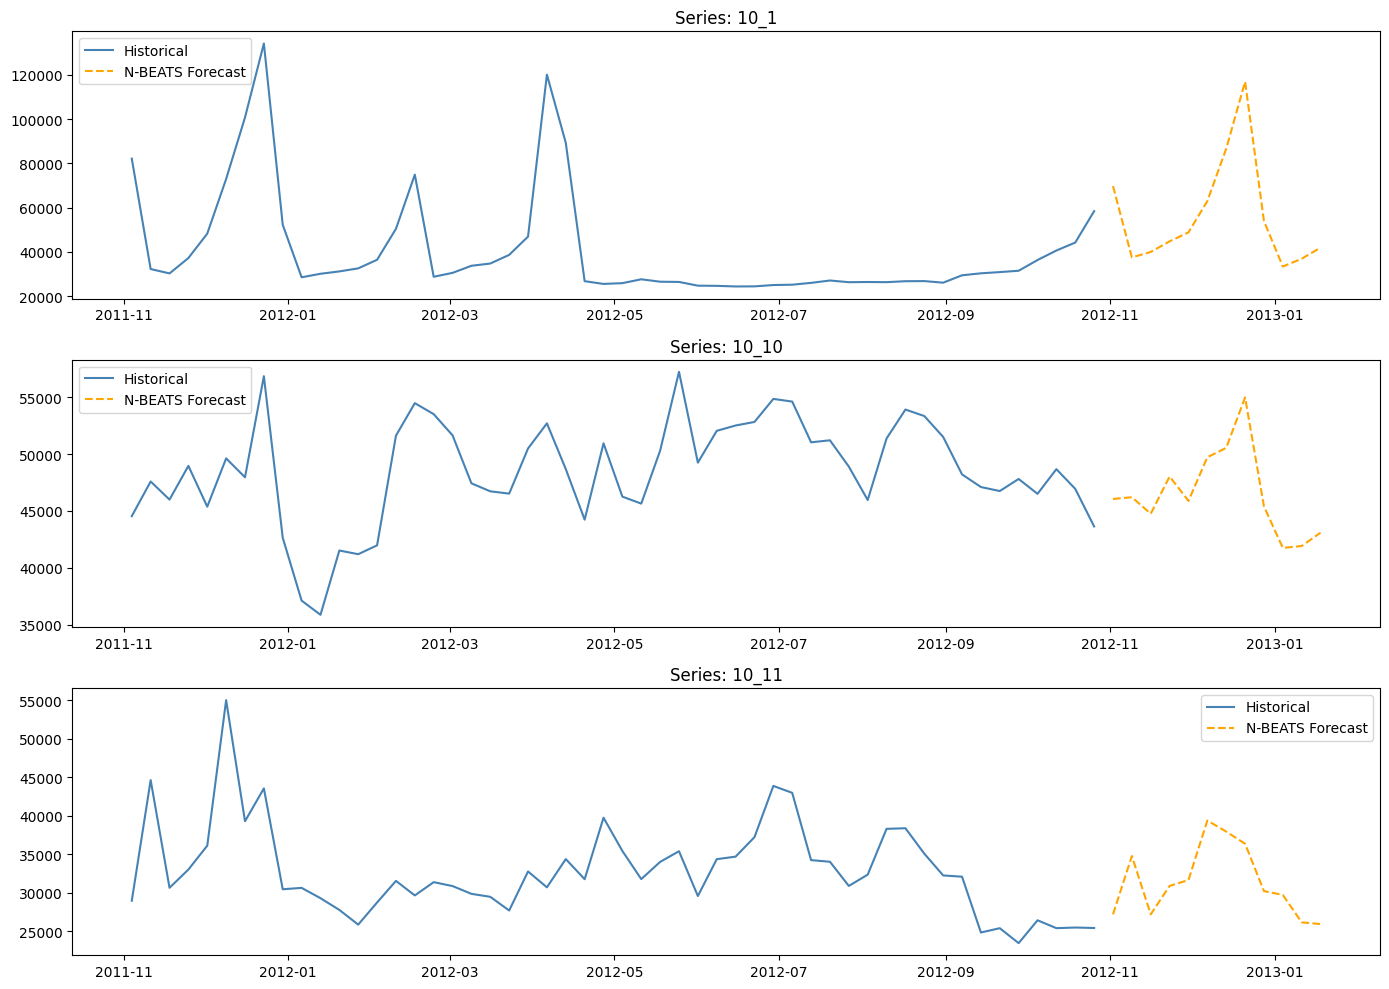

In [22]:
# ვიზუალიზაცია — რამდენიმე time series-ის actual vs predicted
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, uid in zip(axes, sample_ids[:3]):
    # Historical
    hist = train_full_filtered[train_full_filtered['unique_id'] == uid].tail(52)
    # Forecast
    fc = forecasts_final[forecasts_final['unique_id'] == uid]

    ax.plot(hist['ds'], hist['y'], label='Historical', color='steelblue')
    ax.plot(fc['ds'], fc['NBEATS'], label='N-BEATS Forecast', color='orange', linestyle='--')
    ax.set_title(f'Series: {uid}')
    ax.legend()

plt.tight_layout()
plt.show()

## 10. შეჯამება

N-BEATS-ის სამი კონფიგურაცია გავცადეთ WandB-ზე ლოგირებით:

- **Baseline** — generic stacks, 26-week input
- **Interpretable** — trend + seasonality stacks (N-BEATS-ის მთავარი ღირსება, polynomial + Fourier basis)
- **Long context** — 52-week input window (მთელი წელი წარსული)

**საუკეთესო:** Long context კონფიგურაცია — val WMAE **1378.04**. მოსალოდნელი შედეგია — Walmart-ის ყოველწლიური სეზონურობა (Thanksgiving, Christmas, Super Bowl) 26 კვირიან window-ში ერთხელაც არ ჩანს.

Final მოდელი 1600 steps-ით ვატრენინგე მთელ ტრეინინგ სეტზე, შევინახე Drive-ზე pickle-ად და WandB Artifact-ად. 3000+ time series-ს ერთი global მოდელი ერთდროულად სწავლობს — ეს N-BEATS-ის უპირატესობაა tabular per-series მოდელებთან შედარებით.

XGBoost-თან პირდაპირი შედარება inference notebook-ში იქნება, Kaggle submission-ის ქულის მიხედვით.